# Deep Learning Lab: Recurrent Neural Networks (LSTMs)

## Learning Objectives
By the end of this lab, you will be able to:
1. Understand the architecture and components of RNNs and LSTMs
2. Implement an RNN using PyTorch
3. Apply LSTMs to sequence prediction tasks


## Setup and Imports

In [1]:
# Install any additional packages if needed
!pip install -q torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.3 MB/s eta 0:00:00


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Using device: cuda


## 1. Introduction to Recurrent Neural Networks

### Why RNNs?
Traditional neural networks assume inputs are independent. However, many real-world problems involve **sequential data** where order matters:
- Text and language
- Time series (stock prices, weather)
- Audio and speech
- Video frames

### RNN Architecture

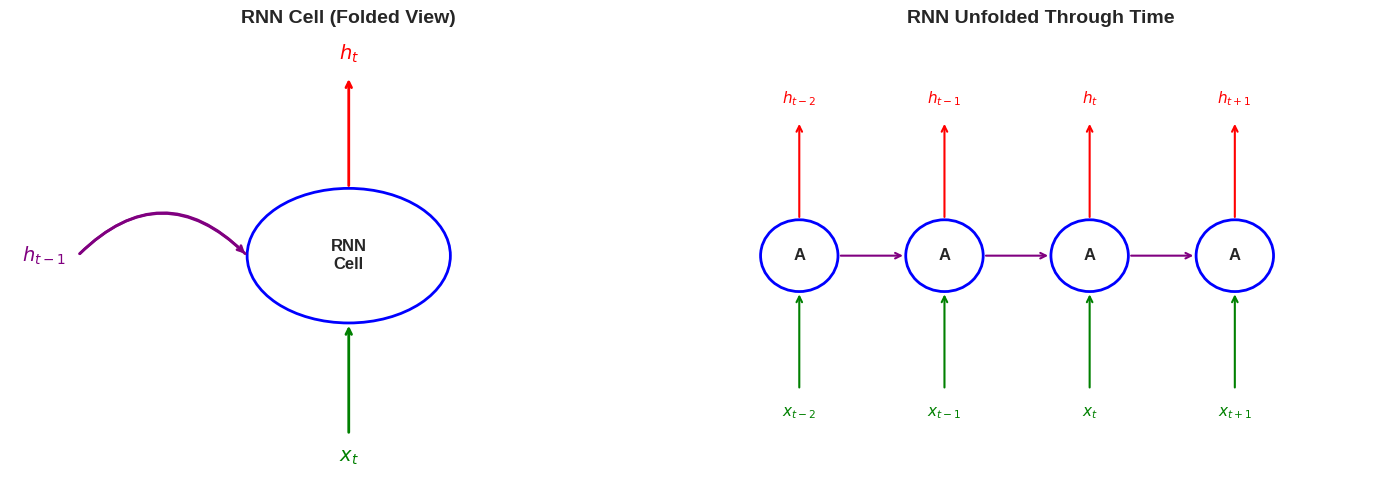

In [3]:
def visualize_rnn_architecture():
    """Visualize the basic RNN architecture"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Folded view
    ax1 = axes[0]
    ax1.set_xlim(0, 10)
    ax1.set_ylim(0, 10)

    # Draw RNN cell
    circle = plt.Circle((5, 5), 1.5, fill=False, color='blue', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(5, 5, 'RNN\nCell', ha='center', va='center', fontsize=12, fontweight='bold')

    # Input arrow
    ax1.annotate('', xy=(5, 3.5), xytext=(5, 1),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax1.text(5, 0.5, '$x_t$', ha='center', va='center', fontsize=14, color='green')

    # Output arrow
    ax1.annotate('', xy=(5, 9), xytext=(5, 6.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax1.text(5, 9.5, '$h_t$', ha='center', va='center', fontsize=14, color='red')

    # Recurrent connection
    ax1.annotate('', xy=(3.5, 5), xytext=(1, 5),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2,
                              connectionstyle='arc3,rad=-0.5'))
    ax1.annotate('', xy=(1, 5), xytext=(3.5, 5),
                arrowprops=dict(arrowstyle='-', color='purple', lw=2,
                              connectionstyle='arc3,rad=0.5'))
    ax1.text(0.5, 5, '$h_{t-1}$', ha='center', va='center', fontsize=14, color='purple')

    ax1.set_title('RNN Cell (Folded View)', fontsize=14, fontweight='bold')
    ax1.axis('off')

    # Unfolded view
    ax2 = axes[1]
    ax2.set_xlim(0, 14)
    ax2.set_ylim(0, 10)

    positions = [2, 5, 8, 11]
    labels = ['t-2', 't-1', 't', 't+1']

    for i, (pos, label) in enumerate(zip(positions, labels)):
        # Draw cell
        circle = plt.Circle((pos, 5), 0.8, fill=False, color='blue', linewidth=2)
        ax2.add_patch(circle)
        ax2.text(pos, 5, 'A', ha='center', va='center', fontsize=12, fontweight='bold')

        # Input
        ax2.annotate('', xy=(pos, 4.2), xytext=(pos, 2),
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
        ax2.text(pos, 1.5, f'$x_{{{label}}}$', ha='center', va='center', fontsize=11, color='green')

        # Output
        ax2.annotate('', xy=(pos, 8), xytext=(pos, 5.8),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
        ax2.text(pos, 8.5, f'$h_{{{label}}}$', ha='center', va='center', fontsize=11, color='red')

        # Horizontal connection
        if i < len(positions) - 1:
            ax2.annotate('', xy=(positions[i+1]-0.8, 5), xytext=(pos+0.8, 5),
                        arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))

    ax2.set_title('RNN Unfolded Through Time', fontsize=14, fontweight='bold')
    ax2.axis('off')

    plt.tight_layout()
    plt.savefig('rnn_architecture.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_rnn_architecture()

### RNN Equations

The basic RNN computes:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$
$$y_t = W_{hy} h_t + b_y$$

Where:
- $x_t$ is the input at time $t$
- $h_t$ is the hidden state at time $t$
- $y_t$ is the output at time $t$
- $W_{hh}, W_{xh}, W_{hy}$ are weight matrices
- $b_h, b_y$ are bias vectors

In [4]:
class SimpleRNN(nn.Module):
    """
    A simple RNN implementation from scratch to understand the mechanics
    """
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size

        # Weight matrices
        # TODO: implement the weights and biases for this RNN
        self.W_xh = nn.Linear(input_size, hidden_size, bias=False)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=True)
        self.W_hy = nn.Linear(hidden_size, output_size, bias=True)

    def forward(self, x, hidden=None):
        """
        x: (batch_size, seq_len, input_size)
        """
        batch_size, seq_len, _ = x.size()

        if hidden is None:
            hidden = torch.zeros(batch_size, self.hidden_size, device=x.device)

        outputs = []
        hiddens = [hidden]

        for t in range(seq_len):
            # Get input at time t
            x_t = x[:, t, :]

            # Compute new hidden state
            hidden = torch.tanh(self.W_xh(x_t) + self.W_hh(hidden))
            hiddens.append(hidden)

            # Compute output
            output = self.W_hy(hidden)
            outputs.append(output)

        outputs = torch.stack(outputs, dim=1)
        hiddens = torch.stack(hiddens[1:], dim=1)

        return outputs, hiddens

# Test the simple RNN
simple_rnn = SimpleRNN(input_size=10, hidden_size=20, output_size=5)
test_input = torch.randn(2, 15, 10)  # batch=2, seq_len=15, input_size=10
output, hidden_states = simple_rnn(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Hidden states shape: {hidden_states.shape}")

Input shape: torch.Size([2, 15, 10])
Output shape: torch.Size([2, 15, 5])
Hidden states shape: torch.Size([2, 15, 20])


# Solution
<details>
<summary>Click here for solution</summary>

```python
self.W_xh = nn.Linear(input_size, hidden_size, bias=False)
self.W_hh = nn.Linear(hidden_size, hidden_size, bias=True)
self.W_hy = nn.Linear(hidden_size, output_size, bias=True)


## 2. The Vanishing Gradient Problem

RNNs suffer from the **vanishing gradient problem** during backpropagation through time (BPTT).

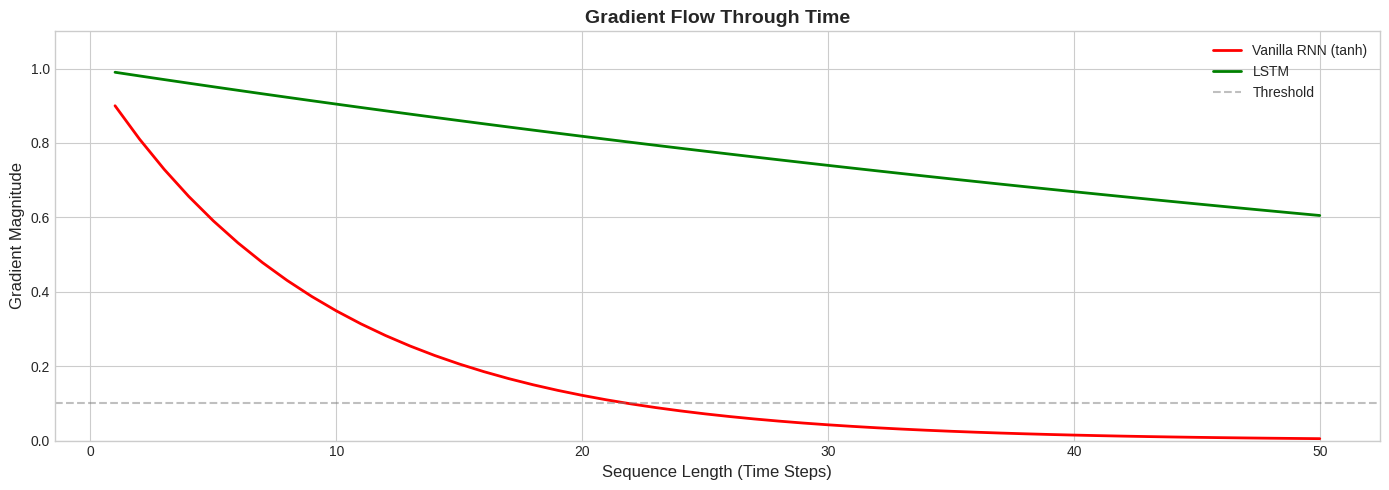

In [6]:
def visualize_vanishing_gradient():
    """Demonstrate the vanishing gradient problem"""
    fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))

    # Simulate gradient flow
    seq_lengths = range(1, 51)

    # RNN with tanh (gradients vanish)
    tanh_gradients = [0.9 ** t for t in seq_lengths]

    # LSTM (gradients preserved better)
    lstm_gradients = [0.99 ** t for t in seq_lengths]

    ax1.plot(seq_lengths, tanh_gradients, 'r-', linewidth=2, label='Vanilla RNN (tanh)')
    ax1.plot(seq_lengths, lstm_gradients, 'g-', linewidth=2, label='LSTM')
    ax1.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='Threshold')
    ax1.set_xlabel('Sequence Length (Time Steps)', fontsize=12)
    ax1.set_ylabel('Gradient Magnitude', fontsize=12)
    ax1.set_title('Gradient Flow Through Time', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.set_ylim(0, 1.1)

    plt.tight_layout()
    plt.savefig('vanishing_gradient.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_vanishing_gradient()

## 3. LSTM Architecture
LSTMs solve the vanishing gradient problem using **gates** and a **cell state**.

### LSTM Gates:
1. **Forget Gate ($f_t$)**: Decides what to forget from the cell state
2. **Input Gate ($i_t$)**: Decides what new information to store
3. **Output Gate ($o_t$)**: Decides what to output based on cell state

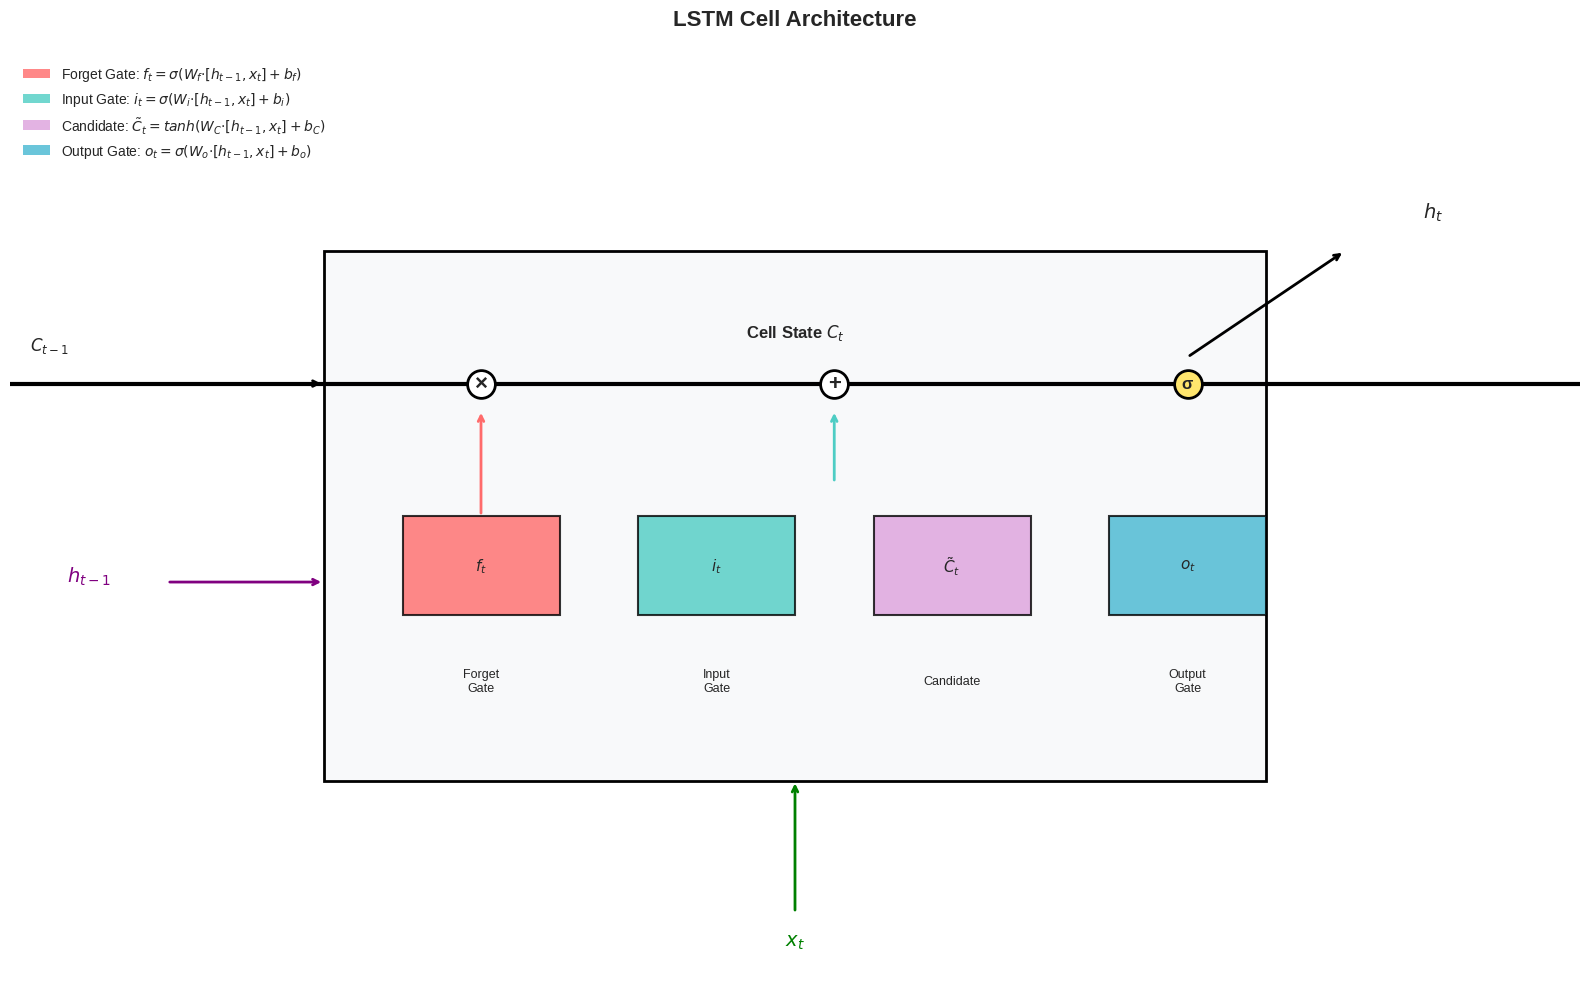


LSTM EQUATIONS

1. Forget Gate:     f_t = σ(W_f · [h_{t-1}, x_t] + b_f)
2. Input Gate:      i_t = σ(W_i · [h_{t-1}, x_t] + b_i)
3. Candidate:       C̃_t = tanh(W_C · [h_{t-1}, x_t] + b_C)
4. Cell State:      C_t = f_t * C_{t-1} + i_t * C̃_t
5. Output Gate:     o_t = σ(W_o · [h_{t-1}, x_t] + b_o)
6. Hidden State:    h_t = o_t * tanh(C_t)


In [7]:
def visualize_lstm_cell():
    """Create a detailed visualization of an LSTM cell"""
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 14)

    # Colors
    forget_color = '#FF6B6B'
    input_color = '#4ECDC4'
    output_color = '#45B7D1'
    cell_color = '#96CEB4'

    # Main cell body
    cell_rect = plt.Rectangle((4, 3), 12, 8, fill=True, facecolor='#F8F9FA',
                               edgecolor='black', linewidth=2)
    ax.add_patch(cell_rect)

    # Cell state line (horizontal)
    ax.plot([0, 20], [9, 9], 'k-', linewidth=3)
    ax.text(10, 9.7, 'Cell State $C_t$', ha='center', fontsize=12, fontweight='bold')

    # Forget gate
    forget_rect = plt.Rectangle((5, 5.5), 2, 1.5, fill=True, facecolor=forget_color,
                                  edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(forget_rect)
    ax.text(6, 6.25, '$f_t$', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(6, 4.5, 'Forget\nGate', ha='center', va='center', fontsize=9)

    # Input gate
    input_rect = plt.Rectangle((8, 5.5), 2, 1.5, fill=True, facecolor=input_color,
                                 edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(input_rect)
    ax.text(9, 6.25, '$i_t$', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(9, 4.5, 'Input\nGate', ha='center', va='center', fontsize=9)

    # Candidate values
    candidate_rect = plt.Rectangle((11, 5.5), 2, 1.5, fill=True, facecolor='#DDA0DD',
                                     edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(candidate_rect)
    ax.text(12, 6.25, '$\\tilde{C}_t$', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(12, 4.5, 'Candidate', ha='center', va='center', fontsize=9)

    # Output gate
    output_rect = plt.Rectangle((14, 5.5), 2, 1.5, fill=True, facecolor=output_color,
                                  edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.add_patch(output_rect)
    ax.text(15, 6.25, '$o_t$', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(15, 4.5, 'Output\nGate', ha='center', va='center', fontsize=9)

    # Pointwise operations on cell state
    ax.plot(6, 9, 'ko', markersize=20, markerfacecolor='white', markeredgewidth=2)
    ax.text(6, 9, '×', ha='center', va='center', fontsize=16, fontweight='bold')

    ax.plot(10.5, 9, 'ko', markersize=20, markerfacecolor='white', markeredgewidth=2)
    ax.text(10.5, 9, '+', ha='center', va='center', fontsize=16, fontweight='bold')

    # Connections from gates to cell state
    ax.annotate('', xy=(6, 8.6), xytext=(6, 7),
                arrowprops=dict(arrowstyle='->', color=forget_color, lw=2))

    ax.annotate('', xy=(10.5, 8.6), xytext=(10.5, 7.5),
                arrowprops=dict(arrowstyle='->', color=input_color, lw=2))

    # tanh before output
    ax.plot(15, 9, 'ko', markersize=20, markerfacecolor='#FFE66D', markeredgewidth=2)
    ax.text(15, 9, 'σ', ha='center', va='center', fontsize=12, fontweight='bold')

    # Hidden state output
    ax.annotate('', xy=(17, 11), xytext=(15, 9.4),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(18, 11.5, '$h_t$', fontsize=14, fontweight='bold')

    # Input arrows
    ax.annotate('', xy=(10, 3), xytext=(10, 1),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax.text(10, 0.5, '$x_t$', ha='center', fontsize=14, color='green', fontweight='bold')

    ax.annotate('', xy=(4, 6), xytext=(2, 6),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2))
    ax.text(1, 6, '$h_{t-1}$', ha='center', fontsize=14, color='purple', fontweight='bold')

    # Previous cell state
    ax.annotate('', xy=(4, 9), xytext=(1, 9),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(0.5, 9.5, '$C_{t-1}$', ha='center', fontsize=12, fontweight='bold')

    # Legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor=forget_color, alpha=0.8, label='Forget Gate: $f_t = σ(W_f·[h_{t-1}, x_t] + b_f)$'),
        plt.Rectangle((0, 0), 1, 1, facecolor=input_color, alpha=0.8, label='Input Gate: $i_t = σ(W_i·[h_{t-1}, x_t] + b_i)$'),
        plt.Rectangle((0, 0), 1, 1, facecolor='#DDA0DD', alpha=0.8, label='Candidate: $\\tilde{C}_t = tanh(W_C·[h_{t-1}, x_t] + b_C)$'),
        plt.Rectangle((0, 0), 1, 1, facecolor=output_color, alpha=0.8, label='Output Gate: $o_t = σ(W_o·[h_{t-1}, x_t] + b_o)$'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    ax.set_title('LSTM Cell Architecture', fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('lstm_architecture.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print equations
    print("\n" + "="*60)
    print("LSTM EQUATIONS")
    print("="*60)
    print("\n1. Forget Gate:     f_t = σ(W_f · [h_{t-1}, x_t] + b_f)")
    print("2. Input Gate:      i_t = σ(W_i · [h_{t-1}, x_t] + b_i)")
    print("3. Candidate:       C̃_t = tanh(W_C · [h_{t-1}, x_t] + b_C)")
    print("4. Cell State:      C_t = f_t * C_{t-1} + i_t * C̃_t")
    print("5. Output Gate:     o_t = σ(W_o · [h_{t-1}, x_t] + b_o)")
    print("6. Hidden State:    h_t = o_t * tanh(C_t)")
    print("="*60)

visualize_lstm_cell()

## Part 1: Character-Level Language Model

In this section, you'll build a character-level LSTM that learns to generate text.

### Dataset: Shakespeare Text

In [8]:
# Download sample text
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, 'shakespeare.txt')

with open('shakespeare.txt', 'r') as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"First 500 characters:\n{'-'*50}")
print(text[:500])

# Create character mappings
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"\nVocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text
encoded_text = torch.tensor([char_to_idx[ch] for ch in text], dtype=torch.long)
print(f"\nEncoded text shape: {encoded_text.shape}")

# TODO: take a look at the first 50 characters of the encoded text
print(f"First 50 encoded chars: {encoded_text[:50].tolist()}")

Total characters: 1,115,394
First 500 characters:
--------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Encoded text shape: torch.Size([1115394])
First 50 encoded chars: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43, 43, 42, 1, 39, 52, 63, 1, 44, 59, 56, 58, 46, 43, 56, 6, 1, 46, 43, 39, 56]


<details>
<summary>Click here for solution </summary>

```python
print(f"First 50 encoded chars: {encoded_text[:50].tolist()}")

In [9]:
class CharDataset(Dataset):
    """Dataset for character-level language modeling"""
    def __init__(self, text_tensor, seq_length):
        self.text = text_tensor
        self.seq_length = seq_length

    def __len__(self):
        return len(self.text) - self.seq_length

    def __getitem__(self, idx):
        # Input sequence
        x = self.text[idx:idx + self.seq_length]
        # Target sequence (shifted by 1)
        y = self.text[idx + 1:idx + self.seq_length + 1]
        return x, y

# Create dataset and dataloader
SEQ_LENGTH = 100
BATCH_SIZE = 64

# TODO create the CharDataset and the DataLoader
dataset = CharDataset(encoded_text, SEQ_LENGTH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Show a sample
x_sample, y_sample = next(iter(dataloader))
print(f"Input batch shape: {x_sample.shape}")
print(f"Target batch shape: {y_sample.shape}")

print(f"\nSample input (first sequence):")
print(''.join([idx_to_char[i.item()] for i in x_sample[0]]))
print(f"\nSample target (first sequence):")
print(''.join([idx_to_char[i.item()] for i in y_sample[0]]))

Input batch shape: torch.Size([64, 100])
Target batch shape: torch.Size([64, 100])

Sample input (first sequence):
 duke my father with his power?

KING RICHARD II:
No matter where; of comfort no man speak:
Let's ta

Sample target (first sequence):
duke my father with his power?

KING RICHARD II:
No matter where; of comfort no man speak:
Let's tal


<details>
<summary>Click here of a solution</summary>

```python
dataset = CharDataset(encoded_text, SEQ_LENGTH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

### Exercise 1: Implement the CharLSTM Model

Complete the `CharLSTM` class below. You need to implement:
1. An embedding layer to convert character indices to vectors
2. An LSTM layer for sequence processing
3. A fully connected layer to predict the next character

**Hints:**
- Use `nn.Embedding(vocab_size, embedding_dim)`
- Use `nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)`
- Use `nn.Linear(hidden_size, vocab_size)` for output


In [10]:
class CharLSTM(nn.Module):
    """
    Character-level LSTM for text generation
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, dropout=0.2):
        super(CharLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # ============================================
        # TODO: Implement the following layers
        # ============================================

        # 1. Embedding layer: converts character indices to dense vectors
        # self.embedding = ???

        # 2. LSTM layer: processes the sequence
        # self.lstm = ???

        # 3. Dropout for regularization
        # self.dropout = ???

        # 4. Fully connected layer: maps hidden states to vocabulary
        # self.fc = ???

        # ============================================
        # YOUR CODE HERE
        # ============================================

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

        # ============================================
        # END OF YOUR CODE
        # ============================================

    def forward(self, x, hidden=None):
        """
        Forward pass

        Args:
            x: Input tensor of shape (batch_size, seq_length)
            hidden: Tuple of (h_0, c_0) or None

        Returns:
            output: Predictions of shape (batch_size, seq_length, vocab_size)
            hidden: Tuple of (h_n, c_n)
        """
        # ============================================
        # TODO: Implement the forward pass
        # ============================================
        # 1. Pass x through embedding layer
        # 2. Pass through LSTM
        # 3. Apply dropout
        # 4. Pass through fully connected layer

        # ============================================
        # YOUR CODE HERE
        # ============================================

        # Embed the input
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Pass through LSTM
        lstm_out, hidden = self.lstm(embedded, hidden)  # (batch, seq_len, hidden)

        # Apply dropout
        lstm_out = self.dropout(lstm_out)

        # Get predictions
        output = self.fc(lstm_out)  # (batch, seq_len, vocab_size)

        # ============================================
        # END OF YOUR CODE
        # ============================================

        return output, hidden

    def init_hidden(self, batch_size, device):
        """Initialize hidden state"""
        h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        c_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        return (h_0, c_0)

# Solution
<details>
<summary>Click here for a solution for part one </summary>
```python
self.embedding = nn.Embedding(vocab_size, embedding_dim)
self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers,
                    batch_first=True, dropout=dropout if num_layers > 1 else 0)
self.dropout = nn.Dropout(dropout)
self.fc = nn.Linear(hidden_size, vocab_size)


<details>
<summary>Click here for a solution for part two</summary>

```python
# Embed the input
embedded = self.embedding(x)  # (batch, seq_len, embed_dim)

# Pass through LSTM
lstm_out, hidden = self.lstm(embedded, hidden)  # (batch, seq_len, hidden)

# Apply dropout
lstm_out = self.dropout(lstm_out)

# Get predictions
output = self.fc(lstm_out)  # (batch, seq_len, vocab_size)

In [11]:
# Test your implementation
model = CharLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_size=256,
    num_layers=2,
    dropout=0.2
).to(device)

# Print model summary
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
test_x = torch.randint(0, vocab_size, (BATCH_SIZE, SEQ_LENGTH)).to(device)
test_out, test_hidden = model(test_x)
print(f"\nTest input shape: {test_x.shape}")
print(f"Test output shape: {test_out.shape}")
print(f"Hidden state shapes: h={test_hidden[0].shape}, c={test_hidden[1].shape}")

CharLSTM(
  (embedding): Embedding(65, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=65, bias=True)
)

Total parameters: 946,625

Test input shape: torch.Size([64, 100])
Test output shape: torch.Size([64, 100, 65])
Hidden state shapes: h=torch.Size([2, 64, 256]), c=torch.Size([2, 64, 256])


### Exercise 2: Implement the Training Loop

Complete the training function below.

In [18]:
def train_char_lstm(model, dataloader, epochs, learning_rate, clip_grad=5.0):
    """
    Train the character-level LSTM

    Args:
        model: The CharLSTM model
        dataloader: Training data loader
        epochs: Number of training epochs
        learning_rate: Learning rate for optimizer
        clip_grad: Gradient clipping threshold

    Returns:
        losses: List of training losses
    """
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        hidden = None

        for batch_idx, (x, y) in tqdm(enumerate(dataloader), desc="Training Model", total=len(dataloader)):
            x, y = x.to(device), y.to(device)

            # ============================================
            # TODO: Implement the training step
            # ============================================
            # 1. Zero the gradients
            # 2. Forward pass
            # 3. Compute loss (reshape output and target appropriately)
            # 4. Backward pass
            # 5. Clip gradients
            # 6. Update weights

            # ============================================
            # YOUR CODE HERE
            # ============================================

            # Zero gradients
            optimizer.zero_grad()

            # Detach hidden state to prevent backprop through time across batches
            if hidden is not None:
                hidden = (hidden[0].detach(), hidden[1].detach())

            # Forward pass
            output, hidden = model(x, hidden)

            # Reshape for loss computation
            # output: (batch, seq_len, vocab) -> (batch * seq_len, vocab)
            # y: (batch, seq_len) -> (batch * seq_len)
            loss = criterion(output.view(-1, vocab_size), y.view(-1))

            # Backward pass
            loss.backward()

            # Clip gradients to prevent exploding gradients
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            # Update weights
            optimizer.step()

            # ============================================
            # END OF YOUR CODE
            # ============================================

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)

        if (epoch + 1) % 1 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

            # Generate sample text
            sample = generate_text(model, "ROMEO:", 100)
            print(f"Sample: {sample}\n")

    return losses

def generate_text(model, start_text, length, temperature=0.8):
    """
    Generate text using the trained model

    Args:
        model: Trained CharLSTM model
        start_text: Starting string for generation
        length: Number of characters to generate
        temperature: Sampling temperature (higher = more random)

    Returns:
        generated: Generated text string
    """
    model.eval()

    # Convert start text to tensor
    chars_tensor = torch.tensor([char_to_idx[ch] for ch in start_text],
                                dtype=torch.long).unsqueeze(0).to(device)

    generated = start_text
    hidden = None

    with torch.no_grad():
        # Process the starting text
        for i in range(len(start_text) - 1):
            output, hidden = model(chars_tensor[:, i:i+1], hidden)

        # Generate new characters
        current_char = chars_tensor[:, -1:]

        for _ in range(length):
            output, hidden = model(current_char, hidden)

            # Apply temperature
            output = output.squeeze() / temperature
            probs = F.softmax(output, dim=-1)

            # Sample from the distribution
            next_idx = torch.multinomial(probs, 1).item()
            next_char = idx_to_char[next_idx]

            generated += next_char
            current_char = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    model.train()
    return generated

# Solution

<details>
<summary>Click here for a solution</summary>

```python
# Zero gradients
optimizer.zero_grad()

# Detach hidden state to prevent backprop through time across batches
if hidden is not None:
    hidden = (hidden[0].detach(), hidden[1].detach())

# Forward pass
output, hidden = model(x, hidden)

# Reshape for loss computation
# output: (batch, seq_len, vocab) -> (batch * seq_len, vocab)
# y: (batch, seq_len) -> (batch * seq_len)
loss = criterion(output.view(-1, vocab_size), y.view(-1))

# Backward pass
loss.backward()

# Clip gradients to prevent exploding gradients
nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

# Update weights
optimizer.step()

In [19]:
# Train the model
print("Training Character LSTM...")
print("="*60)

losses = train_char_lstm(
    model=model,
    dataloader=dataloader,
    epochs=1,  # Increase for better results
    learning_rate=0.002,
    clip_grad=5.0
)

Training Character LSTM...


Training Model: 100%|██████████| 17426/17426 [05:25<00:00, 53.58it/s]


Epoch [1/1], Loss: 1.2320
Sample: ROMEO:
Methinks thou takest me to him to see thee but yours,
And sleep with one departure of the correcteo



In [ ]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Character LSTM Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('char_lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Generate text with different temperatures
print("\n" + "="*60)
print("TEXT GENERATION WITH DIFFERENT TEMPERATURES")
print("="*60)

for temp in [0.5, 0.8, 1.0, 1.5]:
    print(f"\n🌡️ Temperature: {temp}")
    print("-"*40)
    generated = generate_text(model, "JULIET:\n", 200, temperature=temp)
    print(generated)